# 1. Imports & Setup

In [1]:
import sys
!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# 2.LOAD & SPLIT DATA

In [4]:
import pandas as pd
df = pd.read_csv('cleaned_diabetes.csv')

In [5]:
# Split into Features (X) and Target (y)
X = df.drop(columns=['readmitted'])
y = df['readmitted']

In [6]:
# Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Initial Training Data Shape: {X_train.shape}")

Initial Training Data Shape: (81412, 44)


# 3. PREPROCESSING (SCALING & PCA)

In [7]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Apply PCA to keep 95% of the variance

In [8]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [9]:
print(f"Original dimensions before PCA: {X_train_scaled.shape[1]}")
print(f"Dimensions kept after PCA: {pca.n_components_}")

Original dimensions before PCA: 44
Dimensions kept after PCA: 38


# 4. HANDLE CLASS IMBALANCE (SMOTE)

Balance the training data using SMOTE

In [10]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pca, y_train)

print(f"\nOriginal training target distribution:\n{y_train.value_counts()}")
print(f"Resampled training target distribution:\n{y_train_resampled.value_counts()}")


Original training target distribution:
readmitted
2    43912
1    28428
0     9072
Name: count, dtype: int64
Resampled training target distribution:
readmitted
2    43912
1    43912
0    43912
Name: count, dtype: int64


# 5. MODEL TRAINING

In [11]:
from sklearn.ensemble import RandomForestClassifier

Initialize and train the Random Forest model

In [12]:
# Initialize an optimized Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15, 
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Uses all CPU cores
)

In [13]:
# Train the model on the balanced data
print("\nTraining Random Forest Model (This might take a minute)...")
rf_model.fit(X_train_resampled, y_train_resampled)


Training Random Forest Model (This might take a minute)...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [14]:
# Make predictions
predictions = rf_model.predict(X_test_pca)

# 6. EVALUATION & VISUALIZATION

In [15]:
# Print the overall accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"\nOverall Test Accuracy: {accuracy:.4f}\n")


Overall Test Accuracy: 0.5012



In [16]:
# Print the detailed classification report
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.28      0.22      2285
           1       0.44      0.38      0.41      7117
           2       0.64      0.63      0.63     10952

    accuracy                           0.50     20354
   macro avg       0.42      0.43      0.42     20354
weighted avg       0.52      0.50      0.51     20354



In [17]:
# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, predictions)

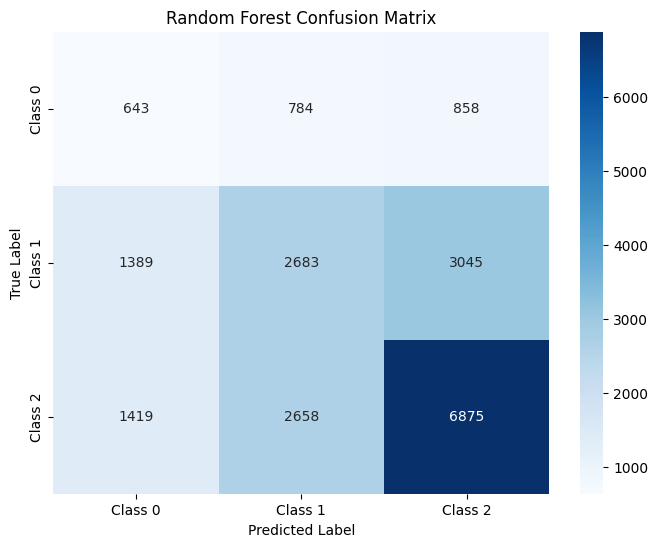

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1', 'Class 2'], 
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()